# Roman kinematic lensing: the band-power data vector and baryonic feedback

**Kinematic lensing (KL)** measures shear from disk galaxies whose rotation is
observed spectroscopically: the velocity field fixes each galaxy's intrinsic
orientation, so comparing it with the observed image isolates the lensing shear
(Xu et al., [arXiv:2201.00739](https://arxiv.org/abs/2201.00739)). The shape
noise per galaxy is far below that of ordinary weak lensing: the project's
covariance notebook assumes a shape dispersion of 0.035, summed in quadrature
over both components, where the `roman_fourier` project assumes 0.30 per
component. The spectra also give each galaxy's redshift, so the ten tomographic
bins (redshift slices of the source sample) are narrow. KL here means kinematic
lensing, not a Karhunen–Loève compression: the likelihood compresses nothing.

**The data vector.** CosmoLike predicts the angular power spectrum of the shear
E mode, $C_\ell^{EE}$, for every pair of source bins $(i,j)$ with $i\le j$: 55
pairs of the 10 bins. Each spectrum enters the likelihood as 20 **band powers**,
averages of $C_\ell$ over logarithmic bands of multipoles between $\ell=20$ and
$\ell=4000$; the model is evaluated at the logarithmic center of each band. The
dataset stores these values in the layout of a Fourier 3×2pt analysis, 3,300
entries in all, and its mask keeps the 1,100 shear entries.

**This notebook** sets up CosmoLike with the settings of the cosmic-shear example
`EXAMPLE_EVALUATE1.yaml`, computes the fiducial band powers and their $\chi^2$,
and applies the six baryonic-feedback models of the `bfmt` theory block to show
how each one changes the band powers and the $\chi^2$. The covariance of the
measurements, the error side of the analysis, is the subject of
[EXAMPLE_EVALUATE_COVARIANCE.ipynb](EXAMPLE_EVALUATE_COVARIANCE.ipynb): it
computes the Gaussian, super-sample and connected non-Gaussian covariance of the
Fourier 3×2pt configuration and compares it with the supplied matrix. This
notebook reads the supplied cosmic-shear covariance, as the likelihood does.

**Model and data.** The settings and the fiducial point are those of
`EXAMPLE_EVALUATE1.yaml`:

| Choice | Value |
| --- | --- |
| Dataset | `data/roman_kl_mcmc.dataset`, cosmic shear |
| Source bins | 10, from `data/Roman_tomo_Ntomo10_src.nz` |
| Band powers | 20 per bin pair, logarithmic bands from $\ell=20$ to 4000 |
| Data-vector entries | 3,300 in the 3×2pt layout; `data/roman_kl.mask` keeps the 1,100 shear entries |
| Stored data vector | `data/roman_kl_2.modelvector`, synthetic: a model prediction, not a measurement |
| Covariance | `data/Roman_cov_Ncl20_Ntomo10.cv`, supplied with the dataset |
| Cosmology | $\Omega_m=0.3156$, $\Omega_b=0.0491685$, $H_0=67.27$, $n_s=0.9645$, $10^9A_s=2.128048$, $w_0=-1$, $w_a=0$, $\sum m_\nu=0.06$ eV |
| Nonlinear matter power | halofit (Takahashi version) |
| Intrinsic alignment | NLA with amplitude $A_1=0$: no intrinsic-alignment signal |
| Nuisance parameters | photo-z shifts and shear calibrations of the 10 source bins, all 0 |

Words used throughout:

- The **data vector** stacks every predicted band power into one long vector;
  the **mask** holds one 0/1 flag per entry, the likelihood's scale cuts.
- **Cobaya** is the framework in which Cocoa's likelihoods run. A **theory
  block** is a Cobaya component that computes a product other components
  request: CAMB's power spectra, or the suppression $S(k,z)$ of `bfmt`.
- An **emulator** is an interpolator trained on a suite of simulations, which
  replaces running them; it is valid inside the parameter box it was trained on.
- $\chi^2=(d-m)^{\mathsf T}C^{-1}(d-m)$ measures the distance between a
  prediction $m$ and the stored data vector $d$ in units of the covariance $C$,
  summed over the entries the mask keeps.

**Conventions.** Arrays count bins from 0 and panel labels from 1. CosmoLike
reads wavenumbers $k$ in $h$/Mpc; the `bfmt` block reads them in 1/Mpc. The
feedback figures compare each method with the prediction without feedback: the
band-power panels show (with feedback)/(without feedback) − 1, the data-vector
figure the same change in percent.

**Before running.** Compile the project (see the
[project README](README.md#notebooks)) and install `bfmt` with its emulators:
the [baryonic feedback section](README.md#roman_kl_baryonic_feedback) of the
README lists the installation keys that must stay commented out. Start Jupyter
from a shell where `start_cocoa.sh` was sourced and restart the kernel after any
recompilation. The plotting style sets `text.usetex = True`, which needs a LaTeX
installation. Sections 4 and 5 run CAMB 14 times: once for the fiducial
prediction of section 4, once for the reference of section 5, and twice per
feedback method (in the Cobaya model that computes the suppression and in the
prediction that applies it). The notebook writes no files.

**Contents**

1. Set up Python, CAMB and the plotting style
2. Mirror the YAML settings and the fiducial point
3. Initialize the interface with the cosmic-shear data
4. The fiducial KL band powers and their $\chi^2$
5. Baryonic feedback from the `bfmt` theory block

## 1. Set up Python, CAMB and the plotting style

The first cell sets the number of OpenMP threads of the compiled code before
importing it, and keeps BLAS, the linear-algebra library under NumPy, on one
thread: the compiled CosmoLike loops own the parallel workers. It imports the
numerical libraries and the compiled interface `ci`
(`cosmolike_roman_kl_interface`, this project's CosmoLike library, built by its
compile script), and sets the figure style through Matplotlib's `rcParams`, the
defaults of every figure. The shared plotting functions never change
`rcParams`, so this cell alone controls fonts and LaTeX rendering. The last
lines only widen the notebook page. Lower `OMP_NUM_THREADS` on a machine with
fewer than eight cores.

The second cell imports CAMB, the Boltzmann code that computes the linear and
nonlinear matter power spectra, from `external_modules/code/CAMB`, the folder
the YAML's `camb` block names, and `cnu` (`cosmolike_notebook_utils`), the CAMB
packaging and plotting helpers shared by every project. It prints where each
one was found. This project has no notebook-wrapper module: the notebook defines
its two functions itself, in sections 4 and 5.

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import os
import sys
# The OpenMP runtime reads OMP_NUM_THREADS when it starts, so the value is set
# before the compiled interface is imported below; 8 matches the project
# README. BLAS stays on one thread (OpenBLAS reads its variable when NumPy
# loads it): the compiled CosmoLike loops own the OpenMP workers.
os.environ['OMP_NUM_THREADS'] = '8'
os.environ['OPENBLAS_NUM_THREADS'] = '1'
import matplotlib
from matplotlib import pyplot as plt
import numpy as np
from getdist import IniFile
import cosmolike_roman_kl_interface as ci
print(sys.version)
print(os.getcwd())

# CosmoLike's OpenMP team size. compute_probes (section 4) restores it before
# every evaluation, as the likelihood does: some libraries lower the
# process-wide thread count without saying so.
COSMOLIKE_OMP_THREADS = int(os.environ['OMP_NUM_THREADS'])

# Figure style of the whole notebook: the shared plotting functions never change
# rcParams, so these lines set every font, tick and grid default.
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
matplotlib.rcParams['mathtext.rm'] = 'Bitstream Vera Sans'
matplotlib.rcParams['mathtext.it'] = 'Bitstream Vera Sans:italic'
matplotlib.rcParams['mathtext.bf'] = 'Bitstream Vera Sans:bold'
matplotlib.rcParams['xtick.bottom'] = True
matplotlib.rcParams['xtick.top'] = False
matplotlib.rcParams['ytick.right'] = False
matplotlib.rcParams['axes.edgecolor'] = 'black'
matplotlib.rcParams['axes.linewidth'] = '1.0'
matplotlib.rcParams['axes.labelsize'] = 'medium'
matplotlib.rcParams['axes.grid'] = True
matplotlib.rcParams['grid.linewidth'] = '0.0'
matplotlib.rcParams['grid.alpha'] = '0.18'
matplotlib.rcParams['grid.color'] = 'lightgray'
matplotlib.rcParams['legend.labelspacing'] = 0.77
matplotlib.rcParams['savefig.bbox'] = 'tight'
matplotlib.rcParams['savefig.format'] = 'pdf'
# text.usetex = True renders every label with LaTeX. It needs texlive-latex-base,
# texlive-latex-extra, texlive-fonts-recommended, dvipng, ghostscript and
# cm-super; set it to False where they are missing.
matplotlib.rcParams['text.usetex'] = True

# Display only: widen the notebook page and the scrollable output area.
import IPython
page_style = "<style>:root { --jp-notebook-max-width: 85% !important; }</style>"
output_style = "<style>div.output_scroll { height: 54em; }</style>"
IPython.display.display(IPython.display.HTML(page_style))
IPython.display.display(IPython.display.HTML(output_style))

3.11.12 | packaged by conda-forge | (main, Apr 10 2025, 22:18:52) [Clang 18.1.8 ]
/Users/vivianmiranda/data/COCOA/september2026/test/cocoa/Cocoa/projects/roman_kl


In [2]:
# CAMB, from external_modules/code/CAMB, the folder the camb block of
# EXAMPLE_EVALUATE1.yaml names. sys.path.insert(0, ...) puts the folder first on
# the module search path; the print shows which build was imported.
sys.path.insert(0, os.environ['ROOTDIR'] + '/external_modules/code/CAMB')
import camb
print('Using CAMB %s installed at %s' % (camb.__version__,
                                         os.path.dirname(camb.__file__)))

# cnu: the CAMB packaging and plotting helpers shared by every project.
sys.path.insert(0, os.environ['ROOTDIR'] + '/external_modules/code/cosmolike_core')
import cosmolike_notebook_utils as cnu
print('Using cosmolike_notebook_utils installed at %s' % os.path.dirname(cnu.__file__))

Using CAMB 1.6.7 installed at /Users/vivianmiranda/data/COCOA/september2026/test/cocoa/Cocoa/external_modules/code/CAMB/camb
Using cosmolike_notebook_utils installed at /Users/vivianmiranda/data/COCOA/september2026/test/cocoa/Cocoa/external_modules/code/cosmolike_core/cosmolike_notebook_utils


## 2. Mirror the YAML settings and the fiducial point

The first cell copies the settings of `EXAMPLE_EVALUATE1.yaml`: the options of
its `roman_kl.cosmic_shear` likelihood block, the defaults of
`likelihood/cosmic_shear.yaml` that the example leaves unchanged, and its `camb`
block. The second cell copies the fiducial point: the
`sampler: evaluate: override` block and the nuisance values the `params` blocks
fix. The later cells read these variables.

The dataset is `roman_kl_mcmc.dataset`, the file `EXAMPLE_EVALUATE1.yaml` names.
The project's frozen test configuration for cosmic shear names the same file.
The default `data_file` of `likelihood/cosmic_shear.yaml`, `roman_kl.dataset`,
is not shipped in `data/`.

Intrinsic alignment (IA), the correlated orientation of galaxies that mimics a
shear signal, uses the nonlinear alignment (NLA) model with a power-law redshift
evolution, and the YAML fixes its amplitude to $A_1=0$: the band powers carry no
IA signal. The parameters of the tidal alignment and tidal torquing (TATT)
model, $A_2$ and $b_{\rm TA}$, are 0 as well, and NLA does not read them. The
project's TATT tests keep $A_1=0$ and set $A_2=0.05$, so they exercise only the
tidal-torquing $A_2$ terms: every $b_{\rm TA}$ term is multiplied by $A_1$.

In [3]:
# Likelihood options of the roman_kl.cosmic_shear block of EXAMPLE_EVALUATE1.yaml,
# with the defaults of likelihood/cosmic_shear.yaml for the options the example
# leaves out.
#
# The dataset: roman_kl_mcmc.dataset, the data_file of EXAMPLE_EVALUATE1.yaml and
# of the frozen cosmic-shear configuration the pytest tests evaluate
# (tests/frozen/frozen_config_example1.py; tests/frozen/data holds byte-identical
# copies of its files, and the chi2 tests swap its data vector for a synthetic
# one generated at the fiducial point). The default of cosmic_shear.yaml,
# roman_kl.dataset, is not shipped in data/. external_modules/data/roman_kl, the
# path of the YAML, is a link to projects/roman_kl/data.
data_path = os.environ['ROOTDIR'] + '/external_modules/data/roman_kl'
data_file = 'roman_kl_mcmc.dataset'
# "xi" is the shared code's name for cosmic shear (from the real-space xi_+/-); in
# this Fourier-space project it selects the band powers C_l^EE
CLprobe = 'xi'
# Every galaxy-shear pair stays in the layout (ggl_exclude: []); the mask of this
# dataset removes them instead.
ggl_exclude = []
accuracyboost = 1.0            # interpolation-table resolution
integration_accuracy = 0       # quadrature level
internal_accuracyboost = 1.0   # C-FAST-PT convolution grid / output grid
nonlimber_accuracyboost = 1.0  # chi grid of the non-Limber projections
photoz_interpolation_type = 0  # n(z) interpolation: 0 = cubic spline
photoz_zmid_convention = 0     # n(z) file z column: 0 = left bin edges
# Nonlinear matter power: 1 = EuclidEmulator2, 2 = halofit.
non_linear_emul = 2
# Intrinsic alignment: model 0 = NLA, 1 = TATT; redshift evolution 3 is a power
# law in (1 + z); IA_code 0 = C FASTPT, 1 = Python FAST-PT (NLA always uses 0).
IA_model = 0
IA_redshift_evolution = 3
IA_code = 0

# The camb block of EXAMPLE_EVALUATE1.yaml. halofit_version takahashi and
# dark_energy_model ppf are fixed inside cnu.get_camb_cosmology. That helper
# scales kmax, k_per_logint and its 1D redshift grid with its CAMB boost: at
# 1.05, kmax = 10 (1 + 3 x 0.05) = 11.5/Mpc, k_per_logint = 51, and 1009 instead
# of 1000 redshifts below z = 3. The likelihood's kmax_boltzmann: 7.5 (1/Mpc)
# sits below camb's kmax, so camb's kmax sets the computed range.
CAMB_ACCURACY_BOOST = 1.05     # AccuracyBoost
CAMB_KMAX = 10.0               # kmax, in 1/Mpc
CAMB_K_PER_LOGINT = 50         # k_per_logint

In [4]:
# The fiducial point: the sampler: evaluate: override block of
# EXAMPLE_EVALUATE1.yaml. As_1e9 = 10^9 A_s; H0 in km/s/Mpc; omegab and
# omegam = Omega_b and Omega_m (omegam counts cold dark matter, baryons and the
# massive neutrinos); mnu = sum of the neutrino masses in eV; w and
# w0pwa = w0 + wa (equal values: wa = 0).
As_1e9 = 2.128048
ns = 0.9645
H0 = 67.27
omegab = 0.0491685
omegam = 0.3156
mnu = 0.06
w = -1.0
w0pwa = -1.0

# Nuisance parameters, one entry per source bin (ROMAN_KL_M1 ... ROMAN_KL_M10 and
# ROMAN_KL_DZ_S1 ... ROMAN_KL_DZ_S10 of the override block, all 0): the shear
# calibration m (the shear of bin i is scaled by 1 + m_i) and the photo-z shift
# (n_i(z) is evaluated at z - Delta z_i). n_source_bins repeats the dataset's
# source_ntomo; section 3 checks it against the file.
n_source_bins = 10
M_FID = np.zeros(n_source_bins)
SHEAR_PHOTOZ_FID = np.zeros(n_source_bins)

# Intrinsic alignment: the values the params block of EXAMPLE_EVALUATE1.yaml fixes
# (ROMAN_KL_BTA_1 from likelihood/params_source.yaml). With
# IA_redshift_evolution = 3 the IA vectors hold parameter slots, not bins:
# slot 1 = amplitude, slot 2 = exponent of the (1 + z) power law, the other
# slots unused. Every value is 0, so the band powers carry no IA signal.
ROMAN_KL_A1_1 = 0.0   # NLA (tidal alignment) amplitude A1
ROMAN_KL_A1_2 = 0.0   # its redshift exponent
ROMAN_KL_A2_1 = 0.0   # TATT tidal-torquing amplitude A2 (NLA does not read it)
ROMAN_KL_A2_2 = 0.0   # its redshift exponent
ROMAN_KL_BTA_1 = 0.0  # TATT density weighting b_TA (NLA does not read it)
A1_FID = np.zeros(n_source_bins)
A1_FID[0] = ROMAN_KL_A1_1
A1_FID[1] = ROMAN_KL_A1_2
A2_FID = np.zeros(n_source_bins)
A2_FID[0] = ROMAN_KL_A2_1
A2_FID[1] = ROMAN_KL_A2_2
BTA_FID = np.zeros(n_source_bins)
BTA_FID[0] = ROMAN_KL_BTA_1

## 3. Initialize the interface with the cosmic-shear data

The dataset file is a small text file of `key = value` lines naming the data
vector (`roman_kl_2.modelvector`), the covariance (`Roman_cov_Ncl20_Ntomo10.cv`),
the mask (`roman_kl.mask`), the n(z) file and the binning: 20 bands between
$\ell=20$ and 4000. The next cell reads it and runs the initialization sequence
of `likelihood/_cosmolike_prototype_base.py`, in the same order:

1. the probe (cosmic shear) and the binning;
2. the galaxy–shear pairs to exclude (none);
3. the n(z) conventions and the accuracy settings;
4. the n(z) files;
5. the covariance, the mask and the data vector;
6. the IA model.

CosmoLike inverts the masked covariance when it reads it, once. The data vector
has the layout of a Fourier 3×2pt analysis: 55 shear rows, 100 galaxy–shear rows
and 10 clustering rows of 20 bands each, 3,300 entries. `roman_kl.mask` keeps the
1,100 shear entries. The cell prints the band centers and both counts.

In [5]:
# The dataset file: key = value lines naming the data vector, covariance, mask
# and n(z) files and the binning. relativeFileName joins a file name with the
# dataset's folder.
ini = IniFile(os.path.join(data_path, data_file))
data_vector_file = ini.relativeFileName('data_file')
cov_file = ini.relativeFileName('cov_file')
mask_file = ini.relativeFileName('mask_file')
lens_nz_file = ini.relativeFileName('nz_lens_file')
source_nz_file = ini.relativeFileName('nz_source_file')
lens_ntomo = ini.int('lens_ntomo')
source_ntomo = ini.int('source_ntomo')
n_bands = ini.int('n_cl')                # band powers per bin pair
ell_min = ini.int('l_min')               # lower edge of the first band
ell_max = ini.int('l_max')               # upper edge of the last band
# a shear band whose center is not below l_max_shear is dropped on top of
# the mask
ell_max_shear = ini.int('l_max_shear')

# The nuisance vectors of section 2 hold one entry per source bin.
if source_ntomo != n_source_bins:
    raise ValueError(
        "the dataset %s has source_ntomo = %d, but section 2 sets "
        "n_source_bins = %d: set n_source_bins to the dataset's value"
        % (data_file, source_ntomo, n_source_bins))

# The init sequence of likelihood/_cosmolike_prototype_base.py, in its order.
# CosmoLike keeps its configuration in C global variables, which these calls
# fill once.
ci.initial_setup()
ci.init_probes(possible_probes=CLprobe)
ci.init_binning(nells=n_bands, lmin=ell_min, lmax=ell_max,
                lmax_shear=ell_max_shear)
# ggl_exclude = the (lens, source) pairs left out of galaxy-shear, flattened for
# the C side ([[0, 0], [1, 0]] -> [0, 0, 1, 0]); here none
ci.init_ggl_exclude(ggl_exclude=np.array(ggl_exclude).flatten())
ci.set_log_level_info()
ci.init_photoz_conventions(interpolation_type=photoz_interpolation_type,
                           zmid_convention=photoz_zmid_convention)
ci.init_fpt_internal_boost(internal_boost=internal_accuracyboost)
ci.init_nonlimber_accuracy_boost(nonlimber_boost=nonlimber_accuracyboost)
# 0 = exact (non-Limber) projection below l = 150 for galaxy-shear and
# clustering; the shear band powers use the Limber approximation at every
# multipole, so these calls only set the state the likelihood sets
ci.init_adopt_limber_gs(adopt_limber_gs=0)
ci.init_adopt_limber_gg(adopt_limber_gg=0)
# 0 = perturbative galaxy bias, not the halo model; 0 = the init_IA model, not
# the halo-model IA
ci.init_include_HOD_GX(include_HOD_GX=0)
ci.init_include_halo_IA(include_halo_IA=0)
ci.init_accuracy_boost(accuracy_boost=accuracyboost,
                       integration_accuracy=integration_accuracy)
# is_linear=False: CosmoLike uses the nonlinear P(k) it is handed
ci.init_cosmo_runmode(is_linear=False)
ci.init_redshift_distributions_from_files(lens_multihisto_file=lens_nz_file,
                                          lens_ntomo=lens_ntomo,
                                          source_multihisto_file=source_nz_file,
                                          source_ntomo=source_ntomo)
# the covariance, mask and stored data vector; CosmoLike inverts the masked
# covariance here, once
ci.init_data_fourier(COV=cov_file, MASK=mask_file, DATA=data_vector_file)
ci.init_IA(ia_model=IA_model,
           ia_redshift_evolution=IA_redshift_evolution,
           ia_code=IA_code)

# mask = one 0/1 flag per data-vector entry; the entries flagged 1 are the data
# points chi2 sums over
mask = np.array(ci.get_mask())
n_kept = int(np.sum(mask))
band_centers = np.array(ci.get_binning_fourier_space())
print("band centers (multipoles):", np.round(band_centers, 1))
print("data vector: %d entries; the mask keeps %d" % (len(mask), n_kept))

band centers (multipoles):

 [  22.8   29.8   38.8   50.5   65.9   85.9  111.9  145.9  190.1  247.8
  322.9  420.8  548.5  714.9  931.7 1214.3 1582.6 2062.7 2688.3 3503.8]
data vector: 3300 entries; the mask keeps 1100


## 4. The fiducial KL band powers and their $\chi^2$

`compute_probes`, defined in the next cell, runs the stages of one likelihood
evaluation at the fiducial point:

1. **CAMB.** `cnu.get_camb_cosmology` computes the linear and nonlinear matter
   power spectra, the growth factor and the distances.
2. **Feedback.** With `sup` given, it adds $\ln S$ to $\ln P_{\rm NL}$ at every
   redshift of the CAMB grid.
3. **Cosmology.** `ci.set_cosmology` copies the tables into the C library,
   after the accuracy settings are installed.
4. **Nuisance parameters.** `ci.set_nuisance_shear_calib`,
   `ci.set_nuisance_shear_photoz` and `ci.set_nuisance_ia` install the fiducial
   values of the 10 source bins.
5. **Observables.** `ci.C_ss_tomo_limber` returns $C_\ell^{EE}$ at the 20 band
   centers, `ci.compute_data_vector_masked` the 3,300-entry data vector with the
   masked entries set to 0, and `ci.compute_chi2` its $\chi^2$.

Section 5 passes `sup`, the feedback suppression; this section calls
`compute_probes()` without it. The second cell prints the fiducial $\chi^2$ and
the number of data points it sums over. The stored data vector,
`data/roman_kl_2.modelvector`, is synthetic (a model prediction shipped with the
dataset, not a measurement), but `tests/cocoa_test_utils.py` records that it sits
away from the current model's prediction at this fiducial point, so this
$\chi^2$ is not zero; the project's tests evaluate synthetic data vectors
regenerated at the fiducial point for that reason.

In [6]:
def compute_probes(sup=None):
    """Compute the KL band powers, the masked data vector and its chi2.

    Runs one likelihood evaluation at the fiducial point of section 2, on the
    interface state of section 3, in five steps: CAMB, the optional feedback
    suppression, the accuracy settings and the cosmology, the source
    nuisance parameters, then the observables. The
    suppression is applied the way the likelihood applies it when
    external_baryon_suppression is on: lnPNL[i :: len(z_grid)] += ln S(z_i).
    It reads the variables of section 2 (fiducial point, likelihood and camb
    settings).

    Arguments:
      sup = None for the prediction without feedback, or the suppression
            {z: S array over k} that get_baryon_suppression (section 5)
            returns on this function's own z_grid and log10k_grid.

    Returns:
      dict with
        ell         = band centers (multipoles), [n_bands];
        C_ss        = C_l^EE at the band centers, [n_bands, n_bins, n_bins];
                      only the pairs (i, j) with i <= j are filled, the
                      other half is 0;
        dv          = theory data vector, [n_data], masked entries 0;
        chi2        = (d - dv)^T C^-1 (d - dv) over the entries the mask
                      keeps, d = the stored data vector;
        z_grid      = redshifts of the P(k) tables, [n_z];
        log10k_grid = log10 of their wavenumbers k in 1/Mpc, [n_k], the
                      unit get_baryon_suppression takes.
      legend: n_bands = band powers per pair (20), n_bins = source bins (10),
      n_data = data-vector entries (3300), n_z and n_k = sizes of the CAMB
      table grid.

    Raises:
      RuntimeError when no data vector is loaded: compute_chi2 would
      otherwise stop the whole Python process.

    Side effects:
      replaces the cosmology, accuracy and nuisance state of the compiled
      interface.
    """
    # The initialization cell of section 3 loads the mask; without it the mask
    # is empty, and the chi2 call below would end the kernel, not raise.
    if len(ci.get_mask()) == 0:
        raise RuntimeError(
            "compute_probes: CosmoLike holds no data vector (its mask has 0 "
            "entries); the chi2 needs the covariance, mask and data vector of "
            "the dataset: run the initialization cell of section 3 first")

    # 1. One CAMB run at the fiducial point with the camb settings of section 2.
    # The tuple holds what ci.set_cosmology consumes; its k grid is log10 of k
    # in h/Mpc, and the 2D tables are flattened with z running fastest.
    (log10k_interp_2D, z_interp_2D, lnPL, lnPNL,
     G_growth, z_growth, z_interp_1D, chi,
     omegan2, lnPL_cb) = cnu.get_camb_cosmology(
        omegam=omegam, omegab=omegab, H0=H0, ns=ns, As_1e9=As_1e9,
        w=w, w0pwa=w0pwa, mnu=mnu,
        kmax=CAMB_KMAX,
        k_per_logint=CAMB_K_PER_LOGINT,
        CAMBAccuracyBoost=CAMB_ACCURACY_BOOST,
        CLAccuracyBoost=accuracyboost,
        non_linear_emul=non_linear_emul)

    # 2. A private copy of ln P_nonlinear, modified in place below.
    lnPNL = np.array(lnPNL, copy=True)
    if sup is not None:
        for i, z_val in enumerate(z_interp_2D):
            # every k entry of redshift z_i sits at stride len(z) in the
            # flattened table, the layout set_cosmology expects. sup[z_val]
            # looks the redshift up by exact float equality, which holds
            # because sup was computed on this same z grid: the CAMB helper
            # rebuilds it identically at every call.
            lnPNL[i :: len(z_interp_2D)] += np.log(sup[z_val])

    # CAMB and other libraries can lower the process-wide OpenMP thread count;
    # the likelihood restores CosmoLike's team before every evaluation.
    ci.set_omp_threads(n=COSMOLIKE_OMP_THREADS)

    # 3. The accuracy settings, then the cosmology. init_fpt_internal_boost
    # comes before init_accuracy_boost, as in the likelihood, so the C-FAST-PT
    # internal grid fraction is the configured one when the boost rescales the
    # tables. This Fourier-space interface has no real-space table, hence no
    # init_ntable_lmax.
    ci.init_photoz_conventions(interpolation_type=photoz_interpolation_type,
                               zmid_convention=photoz_zmid_convention)
    ci.init_fpt_internal_boost(internal_boost=internal_accuracyboost)
    ci.init_accuracy_boost(accuracy_boost=accuracyboost,
                           integration_accuracy=integration_accuracy)
    ci.set_cosmology(omegam=omegam,
                     H0=H0,
                     log10k_2D=log10k_interp_2D,
                     z_2D=z_interp_2D,
                     lnP_linear=lnPL,
                     lnP_nonlinear=lnPNL,
                     G=G_growth,
                     z_1D=z_interp_1D,
                     chi=chi,
                     omegab=omegab,
                     z_G=z_growth,
                     omegan2=omegan2,
                     lnP_linear_cb=lnPL_cb)

    # 4. The source nuisance parameters (cosmic shear has no lens sample).
    # reset_bary_struct switches off the tabulated-simulation contamination of
    # P(k) (init_baryons_contamination), so the only feedback is the S(k, z)
    # of step 2.
    ci.set_nuisance_shear_calib(M=M_FID)
    ci.set_nuisance_shear_photoz(bias=SHEAR_PHOTOZ_FID)
    ci.set_nuisance_ia(A1=A1_FID, A2=A2_FID, B_TA=BTA_FID)
    ci.reset_bary_struct()

    # 5. The band powers at the band centers (C_ss_tomo_limber returns the E-
    # and B-mode cubes; the B modes are not used), the masked data vector, and
    # its chi2 against the stored data vector.
    ell = np.array(ci.get_binning_fourier_space())
    (C_ss, C_ss_BB) = ci.C_ss_tomo_limber(l=ell)
    dv = np.array(ci.compute_data_vector_masked())
    chi2 = ci.compute_chi2(datavector=dv)
    return {"ell": ell, "C_ss": C_ss, "dv": dv, "chi2": chi2,
            "z_grid": z_interp_2D,
            # get_baryon_suppression takes k in 1/Mpc, but the CAMB helper
            # returns this grid in h/Mpc: convert here, at the one place
            # that links the two, so S(k) is evaluated at the physical k.
            "log10k_grid": log10k_interp_2D + np.log10(H0/100.0)}

In [7]:
# fiducial holds ell, C_ss, dv, chi2 and the CAMB grids (compute_probes above)
fiducial = compute_probes()
print("fiducial, no feedback: chi2 = %.4f over %d data points "
      "(the entries the mask keeps of the %d-entry data vector)"
      % (fiducial["chi2"], n_kept, len(fiducial["dv"])))

fiducial, no feedback: chi2 = 0.0391 over 1100 data points (the entries the mask keeps of the 3300-entry data vector)


The next figure draws the fiducial band powers: one panel per source-bin pair
$(i,j)$ of the lower triangle, with $\ell(\ell+1)C_\ell^{EE}/2\pi$ at the 20 band
centers. The panels share one logarithmic range: each panel is multiplied by its
own power of ten, $\alpha$, printed inside it.

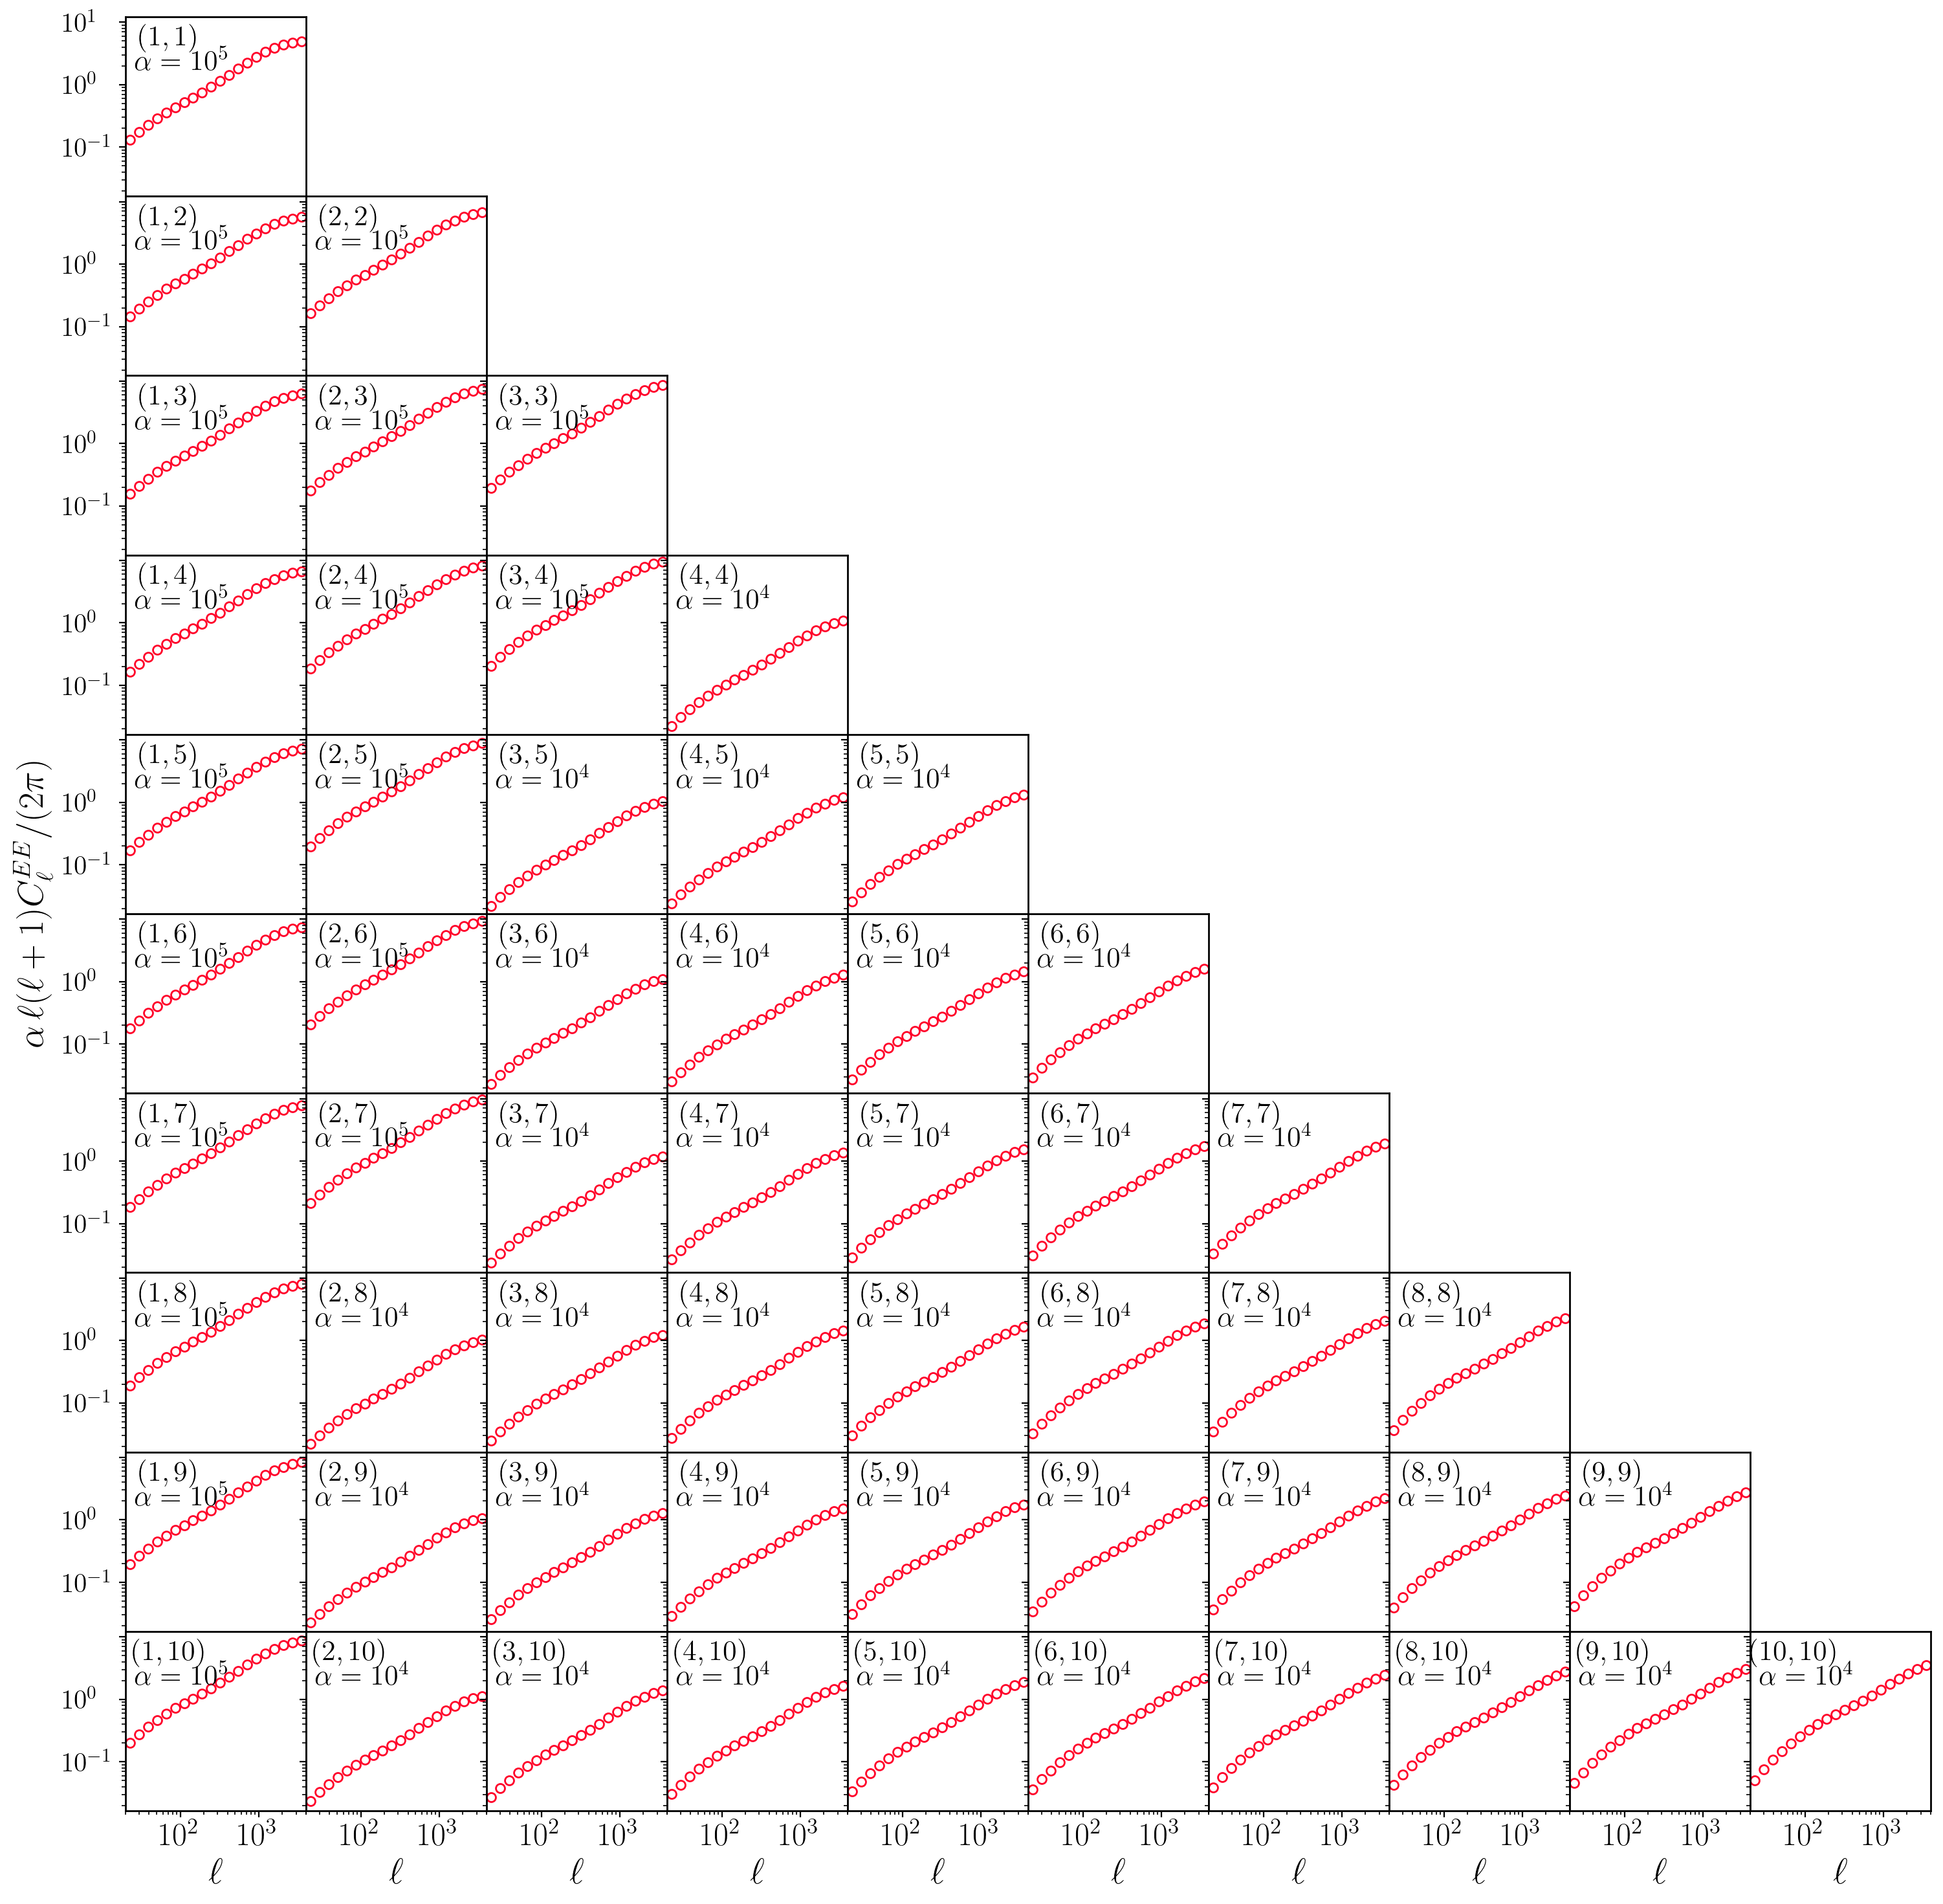

In [8]:
# rescale=1 glues the panels on one y-range, each multiplied by its own power of
# ten alpha; ydecades=4 caps that range at four decades below its top. The band
# powers rise from the lower left of each panel, so the bin label and the alpha
# note both sit in the free upper-left corner.
cnu.plot_C_ss_tomo_limber(ell=fiducial["ell"],
                          C_ss=[fiducial["C_ss"]],
                          lmin=ell_min,
                          lmax=ell_max,
                          marker=["o"],
                          markersize=5,
                          rescale=1,
                          ydecades=4,
                          figsize=(18, 18),
                          bintextpos=[0.25, 0.88],
                          alphatextpos=[0.05, 0.74],
                          bintextsize=16,
                          yaxislabelsize=20,
                          xaxislabelsize=20,
                          xaxisticklabelsize=18,
                          yaxisticklabelsize=15)

## 5. Baryonic feedback from the `bfmt` theory block

Baryonic feedback, the heating and expulsion of gas by active galactic nuclei
and supernovae, suppresses the matter power spectrum on small scales by an
amount that hydrodynamical simulations disagree on. A feedback model returns the
suppression as the ratio $S(k,z)=P_{\rm feedback}(k,z)/P_{\rm DMO}(k,z)$ of the
nonlinear matter power with and without baryonic physics (DMO: dark-matter
only).

The `bfmt` theory block (`external_modules/code/baryon_suppression`) implements
seven ways to compute $S(k,z)$:

- three SP(k) relations (Salcido et al. 2023), which map the baryon fraction
  retained in halos, as a function of halo mass and redshift, to $S(k,z)$; they
  differ in how that fraction depends on mass: a power law, the relation of
  Akino et al. 2022, and a double power law;
- four emulators trained on simulation suites: BCEmu (a baryonification model),
  the FLAMINGO response emulator, BACCOemu and BCemu2025.

The project has a second route to feedback, through tabulated simulations:
`data/baryons_logPkR.h5` stores $\log_{10}S(k,z)$ of eleven hydrodynamical
simulation runs (TNG100, Horizon-AGN, MassiveBlack-II, Illustris, EAGLE, three
OWLS-AGN and three BAHAMAS runs) and of the 400 ANTILLES runs of Salcido et al.
2023, and the likelihood option `add_baryons_on_dv` applies one of them through
`ci.init_baryons_contamination`. That route applies a fixed simulation ratio.
The `bfmt` route evaluates parametric models, the SP(k) relations and the
emulators, whose parameters a chain can sample, and the likelihood calls it when
its option `external_baryon_suppression` is on. The archived script
`old/evaluate_baryon.py` aimed at the same study with the tabulated simulations
and no longer runs (its header lists why); this section carries out its intent
with the `bfmt` block.

This section does not re-implement any model: it drives the block itself through
a minimal Cobaya model of CAMB, `bfmt` and Cobaya's `one` likelihood, a constant
placeholder that lets the model run the theory blocks. The model requests $S$ on
the $(z,k)$ grid of this notebook's CAMB tables, from the same code the CosmoLike
likelihoods call in an MCMC run.

The next cell lists the six methods run here, each as (label, `bfmt` options,
fixed parameter values); BACCOemu is left out of the list, for the reason its
comment gives.

In [9]:
# One entry per feedback method: (label, bfmt options, fixed parameter
# point). The SP(k) points are pyspk's documented examples; the emulator
# points are the fiducial values quoted in the example yamls. BACCOemu
# is commented out so that the table lists the same six methods as the
# other projects' notebooks; it would run here: its omega_baryon training
# box starts at 0.04001, below this project's omegab = 0.0491685.
BARYON_METHODS = [
    ("SP(k) power law", {"baryon_model": 1, "spk_fb_model": 1},
     {"fb_a_spk": 0.4, "fb_pow_spk": 0.3}),
    ("SP(k) Akino et al. 2022", {"baryon_model": 1, "spk_fb_model": 2},
     {"alpha_spk": 4.189, "beta_spk": 1.273, "gamma_spk": 0.298}),
    # this point matches the Akino relation's amplitude at the pivot
    # and stays inside SP(k)'s calibrated baryon-fraction band over
    # the full z grid; pyspk's documented example (0.3, 1.1, 0.2,
    # 0.5) exits the band at z >~ 1.4, and the block then falls back
    # to unity for those redshifts
    ("SP(k) double power law", {"baryon_model": 1, "spk_fb_model": 3},
     {"epsilon_spk": 0.66, "alpha_spk": 0.35, "beta_spk": 0.2,
      "gamma_spk": 0.3}),
    ("BCEmu", {"baryon_model": 2},
     {"log10Mc_bcemu": 13.32, "mu_bcemu": 0.93, "thej_bcemu": 4.235,
      "gamma_bcemu": 2.25, "delta_bcemu": 6.40, "eta_bcemu": 0.15,
      "deta_bcemu": 0.14}),
    ("Flamingo", {"baryon_model": 3},
     {"fgas_sigma_flamingo": 0.0, "mstar_sigma_flamingo": 0.0,
      "jet_frac_flamingo": 0.0}),
    #("BACCOemu", {"baryon_model": 4},
    # {"M_c_baccoemu": 14.0, "eta_baccoemu": -0.3, "beta_baccoemu": -0.22,
    #  "M1_z0_cen_baccoemu": 10.5, "theta_inn_baccoemu": -0.86}),
    ("BCemu2025", {"baryon_model": 5},
     {"Theta_co_bcemu25": 0.3, "log10Mc_bcemu25": 13.1, "mu_bcemu25": 1.0,
      "delta_bcemu25": 6.0, "eta_bcemu25": 0.10, "deta_bcemu25": 0.22,
      "Nstar_bcemu25": 0.028}),
]


### The two functions this section drives

- `get_baryon_suppression(theory_options, point, z_grid, log10k_grid)`, defined
  in the next cell, builds the minimal Cobaya model, evaluates it at the
  fiducial cosmology of section 2 plus the method's parameters, and returns a
  dictionary `{z: S}` with one array over the requested wavenumbers per
  redshift. Each call runs CAMB once. It is the function of the other projects'
  notebook wrappers, reading this notebook's fiducial variables.
- `compute_probes(sup)`, defined in section 4, adds $\ln S(k,z)$ to a copy of the
  nonlinear $\ln P$ table when `sup` is given, the operation the likelihood
  applies, and returns the band powers, the masked data vector, its $\chi^2$
  and the grids `z_grid` and `log10k_grid` of its CAMB tables.

Both read the fiducial values of section 2 at every call and take no cosmology
arguments, so a suppression and the prediction it multiplies always share one
cosmology.

**Units at the handoff.** `cnu.get_camb_cosmology` returns $\log_{10}k$ with $k$
in $h$/Mpc, the unit of `ci.set_cosmology`, while `get_baryon_suppression`, like
the likelihood's request to `bfmt`, reads $k$ in 1/Mpc. The `log10k_grid` that
`compute_probes` returns is therefore $\log_{10}k+\log_{10}h$, with $h=H_0/100$
for $H_0$ in km/s/Mpc: the same nodes, in 1/Mpc. The $h$/Mpc grid handed over
unchanged would evaluate $S$ at $k/h$, about $1.49\,k$ at $h=0.6727$, instead of
at $k$.

In [10]:
def get_baryon_suppression(theory_options, point, z_grid, log10k_grid):
    """Return the suppression S(k, z) of the bfmt theory block on a grid.

    S = P(k) with baryonic feedback / P(k) without it. Builds a minimal
    Cobaya model (CAMB + bfmt + the likelihood "one", which returns
    ln L = 0 and only makes the model complete), requests the
    baryon_suppression product at the given grid (k in 1/Mpc, as the
    Cosmolike likelihoods send it; the block converts to h/Mpc
    internally), evaluates it at this notebook's fiducial cosmology
    (As_1e9, ns, H0, omegab, omegam, mnu and w of section 2), and
    returns {z: S array over k}.

    Arguments:
      theory_options = bfmt options dict, e.g. {"baryon_model": 2}.
      point   = {parameter name: value} for the method's feedback
                parameters, fixed in the model.
      z_grid  = redshifts of the evaluation grid.
      log10k_grid = log10 of the wavenumbers, read as k in 1/Mpc.

    Returns:
      {z: 1D S array over k}, one entry per z_grid value.
    """
    from cobaya.model import get_model
    # Cobaya model description: CAMB at this notebook's fiducial
    # cosmology (tau = 0.0543, a Planck 2018 value, only completes
    # CAMB's input; omch2 subtracts the massive-neutrino density),
    # bfmt with the caller's options and feedback parameters, and
    # debug = 50 (logging.CRITICAL: only critical messages print)
    info = {
        "likelihood": {"one": None},
        "theory": {
            # no "path" for camb: the session already imported it,
            # and cobaya accepts the loaded module as is
            "camb": {"extra_args": {"halofit_version": "takahashi",
                                    "dark_energy_model": "ppf"}},
            "bfmt": dict({"python_path": os.environ["ROOTDIR"]
                          + "/external_modules/code/baryon_suppression"},
                         **theory_options),
        },
        "params": dict({
            "As": {"value": As_1e9*1e-9},
            "ns": ns, "H0": H0, "mnu": mnu, "tau": 0.0543,
            "w": w,
            "ombh2": omegab*(H0/100)**2,
            "omch2": (omegam-omegab)*(H0/100)**2
                     - (mnu*(3.046/3)**0.75)/94.0708,
            "omegam": {"derived": True, "latex": r"\Omega_m"},
        }, **point),
        "debug": 50,
    }
    model = get_model(info)
    model.add_requirements({"baryon_suppression": {
        "z": z_grid, "k": np.power(10.0, log10k_grid)}})
    # every parameter is fixed, so the point to evaluate is the empty
    # dictionary; the call runs CAMB and bfmt once
    model.logposterior({})
    return model.provider.get_baryon_suppression()

### Compute the data vector without and with each method

The first cell repeats the feedback-free computation of section 4 as the
reference `ref` and prints its $\chi^2$ against the stored data vector, the
number of entries that enter $\chi^2$ (1,100) and the length of the masked data
vector (3,300: the masked entries are zero). The stored data vector,
`data/roman_kl_2.modelvector`, is synthetic, a model prediction shipped with the
dataset rather than a measurement, and it sits away from the current model's
prediction at this fiducial point (`tests/cocoa_test_utils.py` records the
offset), so this $\chi^2$ is above zero.

The second cell loops over the six methods: for each it computes $S(k,z)$ on the
$(z,k)$ grid of the CAMB tables, then the prediction with that suppression, and
prints its $\chi^2$. The third cell prints the table, one row per prediction, no
feedback first:

- $\chi^2$ against the stored data vector, over the 1,100 entries the mask keeps;
- $\Delta\chi^2=\chi^2-\chi^2_{\rm none}$, the change from the prediction without
  feedback, of either sign: feedback can move the prediction toward the stored
  data vector or away from it;
- the $\chi^2$ of the shift, $(t-t_{\rm none})^{\mathsf T}C^{-1}(t-t_{\rm none})$,
  with $t$ the masked prediction and $C$ the covariance: the distance between the
  predictions with and without feedback in units of the KL errors, independent
  of the stored values. A value well above one means that the 1,100 band powers
  distinguish the method from no feedback, so an analysis with this mask has to
  model feedback of that strength.

When the stored data vector is close to the no-feedback prediction,
$\Delta\chi^2$ and the $\chi^2$ of the shift nearly coincide. Each method runs
CAMB twice: once in the Cobaya model of `get_baryon_suppression` and once in
`compute_probes`.

In [11]:
# ref holds ell, C_ss, the masked data vector dv, its chi2 and the z and log10 k
# grids of the CAMB tables: the computation of section 4, repeated so this
# section starts from a known interface state
ref = compute_probes()
# n_kept (section 3) = the sum of the mask flags, the number of entries that
# enter chi2
print("no feedback: chi2 = %.4f over %d data points, data vector length = %d"
      % (ref["chi2"], n_kept, len(ref["dv"])))

no feedback: chi2 = 0.0391 over 1100 data points, data vector length = 3300


In [12]:
# For each method: one Cobaya model (CAMB + bfmt) gives S(k, z) on the grid of
# ref, then one data vector with S applied to the nonlinear power.
# ref["log10k_grid"] is already in 1/Mpc, the unit get_baryon_suppression takes.
results = {}
for label, theory_options, point in BARYON_METHODS:
    sup = get_baryon_suppression(theory_options=theory_options,
                                 point=point,
                                 z_grid=ref["z_grid"],
                                 log10k_grid=ref["log10k_grid"])
    results[label] = compute_probes(sup=sup)
    # flush=True prints each line as soon as its method is done
    print("%-28s chi2 = %10.4f" % (label, results[label]["chi2"]), flush=True)

SP(k) power law              chi2 =  3561.5737


SP(k) Akino et al. 2022      chi2 =  1976.9315


SP(k) double power law       chi2 =  1955.2578


BCEmu                        chi2 =  3016.5389


Flamingo                     chi2 =  1216.9889


Loading BCemu2025 models (backend='numpy')...


Loading model weights:   0%|          | 0/21 [00:00<?, ?it/s]

...BCemu2025 emulator is ready.


BCemu2025                    chi2 =   388.4311


In [13]:
# C^-1 as CosmoLike holds it: an n_data x n_data matrix (3300 x 3300 here) whose
# masked rows and columns are zero, the matrix compute_chi2 contracts, so the
# difference of two masked data vectors can be contracted with it directly
inv_cov = np.array(ci.get_inv_cov_masked())

# the label of every (label, bfmt options, point) entry, in table order
labels = [label for label, _, _ in BARYON_METHODS]

print("chi2 over %d data points (the cosmic-shear band powers roman_kl.mask keeps)"
      % n_kept)
print("%-28s %12s %12s %14s" % ("method", "chi2", "Delta chi2", "chi2 of shift"))
# the no-feedback row first, then one row per method
rows = [("no feedback", ref)]
for label in labels:
    rows.append((label, results[label]))
for label, result in rows:
    delta_chi2 = result["chi2"] - ref["chi2"]
    # (t - t_none)^T C^-1 (t - t_none); @ is the matrix product
    shift = result["dv"] - ref["dv"]
    chi2_shift = shift @ inv_cov @ shift
    print("%-28s %12.4f %12.4f %14.4f"
          % (label, result["chi2"], delta_chi2, chi2_shift))

chi2 over 1100 data points (the cosmic-shear band powers roman_kl.mask keeps)
method                               chi2   Delta chi2  chi2 of shift
no feedback                        0.0391       0.0000         0.0000
SP(k) power law                 3561.5737    3561.5347      3540.6941
SP(k) Akino et al. 2022         1976.9315    1976.8924      1961.7222
SP(k) double power law          1955.2578    1955.2188      1940.1364
BCEmu                           3016.5389    3016.4998      2997.5802
Flamingo                        1216.9889    1216.9499      1205.9869
BCemu2025                        388.4311     388.3920       382.8966


### Cosmic shear band powers with feedback: $C_\ell^{EE}$

Each panel is one source-bin pair $(i,j)$ of the lower triangle and shows
$C_\ell^{EE,\,\rm feedback}/C_\ell^{EE,\,\rm none}-1$ at the 20 band centers, one
color per method: the colorbar values only order the methods, the legend at the
top of the figure names them, and the two lightest colors (the second and fourth
methods) are drawn with long dashes. The first cell defines `fitted_ratio_band`,
which fits the band to the curves: from the lowest to the highest drawn value,
zero included, plus 10% of that width at each end. Expect no change at low $\ell$
and a suppression that grows with $\ell$. At a fixed multipole a low-redshift pair
probes larger wavenumbers, $k\approx(\ell+1/2)/\chi$ with $\chi$ the comoving
distance of its lensing kernel, so the suppression is strongest in the upper-left
panels.

In [14]:
def fitted_ratio_band(curves, reference):
    """Return a band (lower, upper) fitted to every curve/reference - 1.

    The band spans the smallest and the largest value of
    curve/reference - 1 over all curves and panels, includes 0 (the
    no-feedback line), and adds 10% of its width at each end, so the
    curves fill the panels without touching the frame. Panels whose
    reference is identically zero are skipped, as the plotters skip
    them: C_ss_tomo_limber fills only the pairs (i, j) with i <= j, and
    the other half of its cube stays zero.

    Arguments:
      curves    = list of arrays [n_x, n_first, n_second], one per method;
                  for C_ss, n_x = band centers and n_first = n_second =
                  source bins.
      reference = the no-feedback array, with the same shape.

    Returns:
      (1 + low - padding, 1 + high + padding): the band written around 1,
      the ylim convention of the cnu plotters with a reference.
    """
    low = 0.0
    high = 0.0
    n_first = reference.shape[1]
    n_second = reference.shape[2]
    for curve in curves:
        for i in range(n_first):
            for j in range(n_second):
                if not np.any(reference[:, i, j]):
                    continue
                ratio = curve[:, i, j]/reference[:, i, j] - 1
                low = min(low, np.min(ratio))
                high = max(high, np.max(ratio))
    padding = 0.1*(high - low)
    return (1 + low - padding, 1 + high + padding)

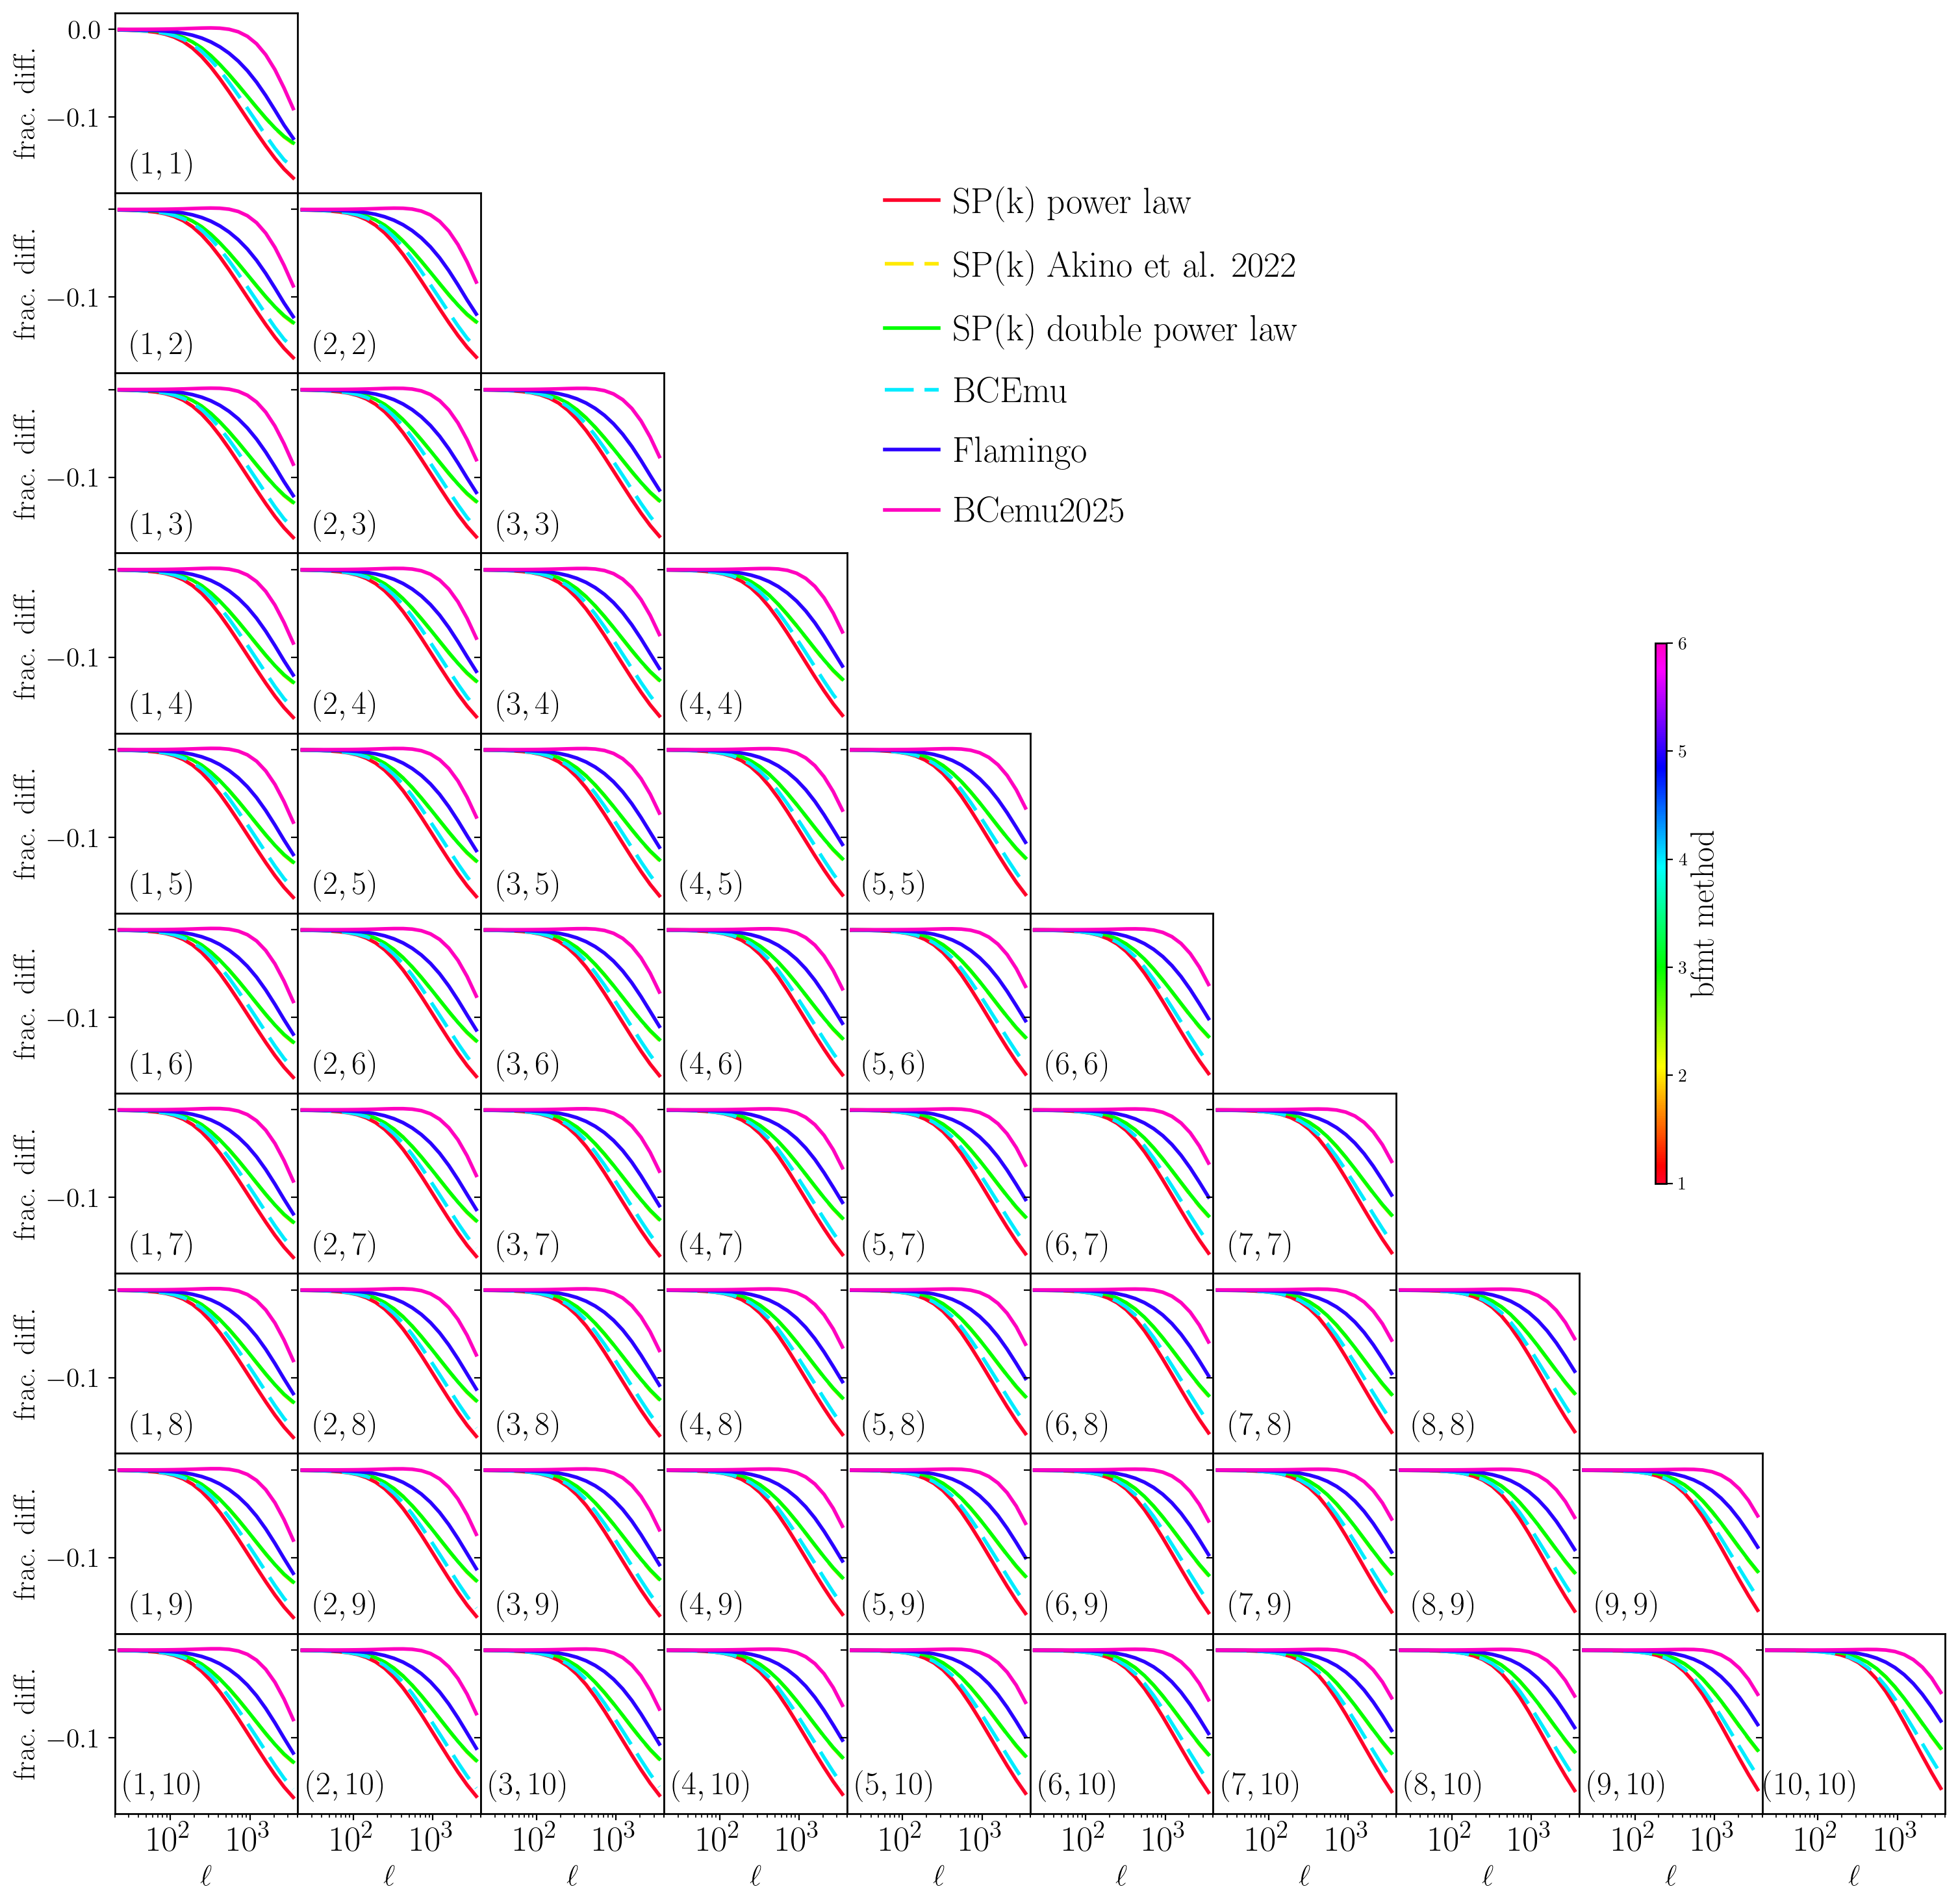

In [15]:
# param only orders the curve colors, one value per method; the legend at the
# top of the figure names the methods
param = np.arange(1.0, 1.0 + len(labels))

# One linestyle per method, in BARYON_METHODS order, so every panel draws a
# method with the same style: the colormap (gist_rainbow, the plotter's default)
# gives the second method a light yellow and the fourth a light cyan, which get
# a long dash ((0, (8, 3)): 8 points drawn, 3 skipped); a wide line (linewidth,
# one entry repeated for every curve) keeps all six curves visible
method_linestyles = ["solid", (0, (8, 3)), "solid", (0, (8, 3)), "solid", "solid"]
if len(method_linestyles) != len(labels):
    raise ValueError(
        "method_linestyles has %d entries for %d methods in BARYON_METHODS: "
        "give one linestyle per method" % (len(method_linestyles), len(labels)))

C_ss_list = []
for label in labels:
    C_ss_list.append(results[label]["C_ss"])

C_ss_band = fitted_ratio_band(curves=C_ss_list, reference=ref["C_ss"])

# legendloc (0.45, 0.72): the lower-left corner of the one-column legend, in
# figure fractions, at the top of the empty upper triangle. bintextpos
# (0.27, 0.15): the lower-left corner of each panel, which the curves leave
# free (they sit at zero at low ell).
cnu.plot_C_ss_tomo_limber(ell=ref["ell"],
                          C_ss=C_ss_list,
                          C_ss_ref=ref["C_ss"],
                          param=param,
                          colorbarlabel="bfmt method",
                          lmin=ell_min,
                          lmax=ell_max,
                          ylim=C_ss_band,
                          legend=labels,
                          legendloc=(0.45, 0.72),
                          linestyle=method_linestyles,
                          linewidth=[2.0],
                          bintextpos=[0.27, 0.15],
                          bintextsize=18,
                          figsize=(18, 18),
                          legendfontsize=20,
                          xaxisticklabelsize=20,
                          yaxisticklabelsize=15,
                          yaxislabelsize=17)

### The masked data vector with feedback

The same predictions as the likelihood reads them: every entry the mask keeps,
in storage order, as the change $100\,(t_{\rm feedback}/t_{\rm none}-1)$ in
percent, with the colors and line styles of the figure above. Within each
source-bin pair the 20 band powers run from low to high $\ell$, so every pair
draws one tooth of a sawtooth. Dotted vertical lines separate the groups of
pairs that share the first bin $i$: $(1,1)$ to $(1,10)$, then $(2,2)$ to
$(2,10)$, and so on. The vertical range is fitted to the curves, with 0 included
and 10% of the span added on each side.

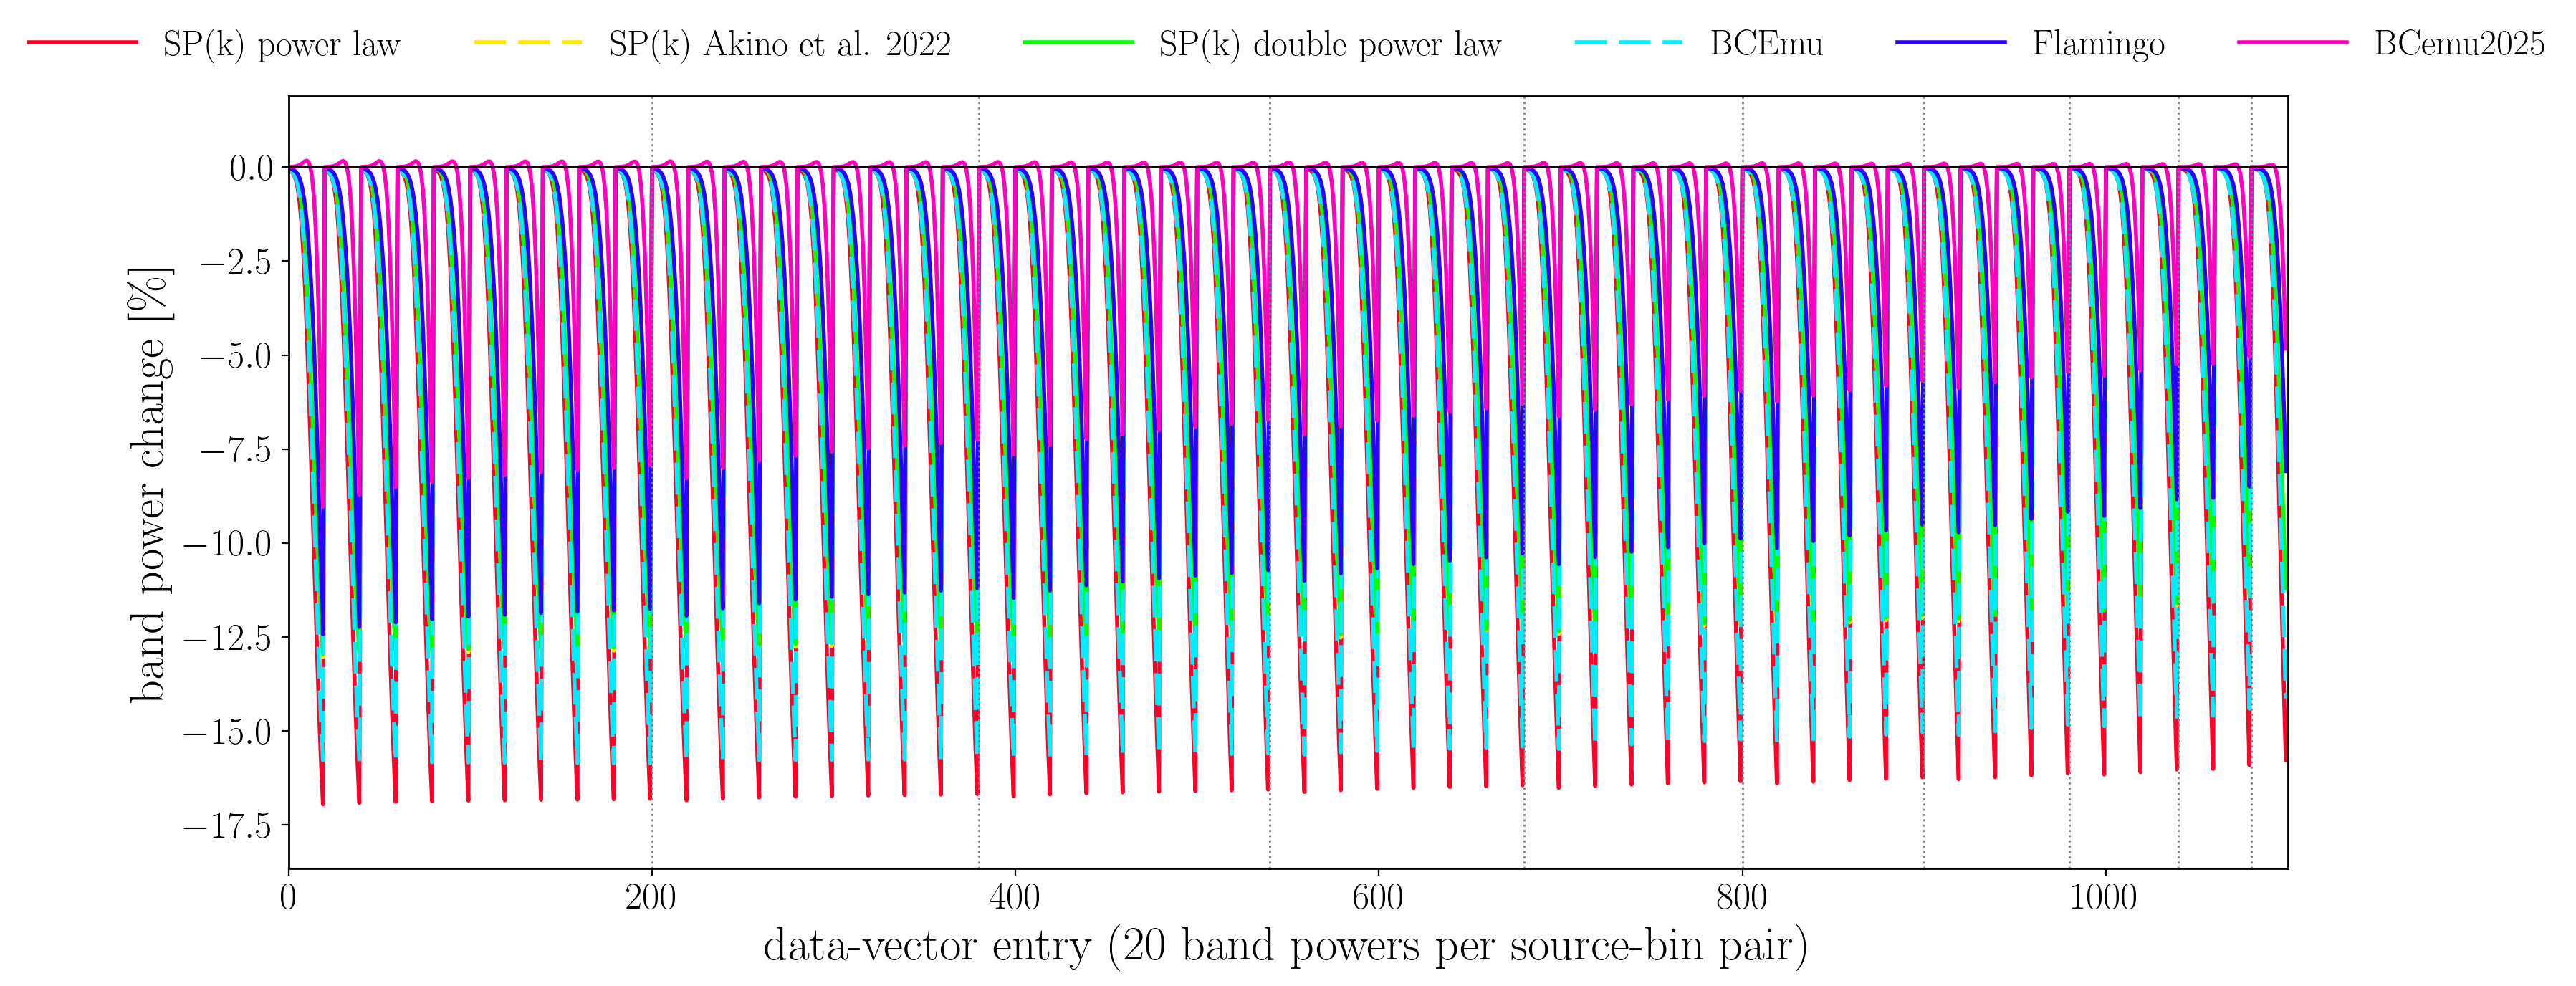

In [16]:
# The color plot_C_ss_tomo_limber gives each method: its param value normalized
# onto the 0..1 axis of the same colormap.
colormap = plt.get_cmap("gist_rainbow")
method_colors = []
for value in param:
    position = (value - param[0])/(param[-1] - param[0])
    method_colors.append(colormap(position))

# kept_entries = the positions of the entries the mask keeps (np.flatnonzero
# returns the indices of the nonzero flags). The change of every kept entry in
# percent, 100 (t_feedback/t_none - 1), and the vertical range fitted to it:
# 0 included, 10% of the span added on each side.
kept_entries = np.flatnonzero(mask)
changes_percent = {}
lowest_change = 0.0
highest_change = 0.0
for label in labels:
    with_feedback = results[label]["dv"][kept_entries]
    without_feedback = ref["dv"][kept_entries]
    change = 100.0*(with_feedback/without_feedback - 1.0)
    changes_percent[label] = change
    lowest_change = min(lowest_change, float(np.min(change)))
    highest_change = max(highest_change, float(np.max(change)))
padding = 0.1*(highest_change - lowest_change)

fig, ax = plt.subplots(figsize=(18, 7))
for index, label in enumerate(labels):
    ax.plot(kept_entries, changes_percent[label],
            color=method_colors[index],
            linestyle=method_linestyles[index],
            linewidth=2.0,
            label=label)

# The data vector stores the pairs (i, j), i <= j, as (1,1), (1,2), ..., (1,10),
# (2,2), ..., with the n_bands band powers of a pair consecutive. The dotted
# lines mark where the first bin changes: the group of first bin b (counted
# from 0) holds n_source_bins - b pairs.
group_end = 0
for first_bin in range(n_source_bins - 1):
    group_end = group_end + (n_source_bins - first_bin)*n_bands
    ax.axvline(x=group_end, color="gray", linestyle="dotted", linewidth=1.0)
ax.axhline(y=0.0, color="black", linewidth=0.8)

ax.set_xlim(kept_entries[0], kept_entries[-1] + 1)
ax.set_ylim(lowest_change - padding, highest_change + padding)
ax.set_xlabel("data-vector entry (%d band powers per source-bin pair)" % n_bands,
              fontsize=24)
ax.set_ylabel(r"band power change [$\%$]", fontsize=24)
ax.tick_params(axis="both", labelsize=19)
# the legend sits above the panel, in one row
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.0), ncols=len(labels),
          fontsize=18, frameon=False, handlelength=3.0)
plt.show()